# NBA 2026

### I have chosen 2 datasets from the NBA 2026 season. The first has individual player stats, and the second has team wins/losses. As a basketball fan, there are many questions that come to mind with this dataset. I would like to explore, disect, and present my findings to a non-basketball fan in an easy to understand manner.

### Questions: 
### 1. What separates the top ranking teams from the bottom teams?
### 2. Do teams need many good players or is one superstar enough?
### 3. Are the players with a large point share effecient or are they just get shooting a lot of shots?
### 4. What percentage of top players points come from free throws?
### 5. Do top players favor 3-pointers?

In [1]:
#Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
from scipy.stats import linregress

In [2]:
%matplotlib inline

# Load the data

In [3]:
#Data from https://www.kaggle.com/datasets/nilesh2042/nba-player-stats-2026
df = pd.read_csv('.\\nba_player_stats_2026.csv')
df.head().T

,0,1,2,3,4
PLAYER_ID,1629029,1628983,1627759,201142,1630178
RANK,1,2,3,4,5
PLAYER,Luka Dončić,Shai Gilgeous-Alexander,Jaylen Brown,Kevin Durant,Tyrese Maxey
TEAM_ID,1610612747,1610612760,1610612738,1610612745,1610612755
TEAM,LAL,OKC,BOS,HOU,PHI
GP,64,68,71,78,70
MIN,2289,2259,2443,2840,2661
FGM,693,731,736,716,694
FGA,1457,1321,1543,1376,1501
FG_PCT,0.476,0.553,0.477,0.52,0.462


In [4]:
df.shape

(582, 28)

In [5]:
#Data for regular season from Google
standings = pd.read_csv('.\\Team Standings 2026.csv')
standings.head()

,Rank,Team Name,Team,Wins,Losses,Win %
0,1,Oklahoma City Thunder,OKC,64,18,0.780
1,2,San Antonio Spurs,SAS,62,20,0.756
2,3,Detroit Pistons,DET,60,22,0.732
3,4,Boston Celtics,BOS,56,26,0.683
4,5,Denver Nuggets,DEN,54,28,0.659


In [6]:
# Define the relevant numeric metrics to sum
relevant_metrics = ['MIN', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

# Group by TEAM and sum
df_team = df.groupby('TEAM')[relevant_metrics].sum()

# Display the first few rows of the team-level DataFrame
df_team.head()

,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
TEAM,,,,,,,,,,,,,,,,
ATL,22243,4009,8526,1287,3547,1472,1933,1158,3006,4164,2617,816,421,1256,1814,10777
BKN,19652,2989,6676,1030,3025,1406,1806,879,2410,3289,1970,668,367,1188,1793,8414
BOS,19365,3453,7320,1183,3253,1214,1506,1046,2921,3967,2050,560,419,932,1514,9303
CHA,19458,3306,7211,1350,3591,1429,1755,1036,2737,3773,2095,546,368,1156,1549,9391
CHI,17976,3108,6740,1053,2976,1351,1734,773,2458,3231,2080,568,368,1160,1473,8620


In [7]:
# Recalculate these 3 percentages
df_team['FG_PCT'] = df_team['FGM']/df_team['FGA']
df_team['FG3_PCT'] = df_team['FG3M']/df_team['FG3A']
df_team['FT_PCT'] = df_team['FTM']/df_team['FTA']

In [8]:
# Normalize by minutes because some teams play overtime games which adds time
df_team_normalized = df_team[relevant_metrics].div(df_team['MIN'], axis=0)

# Display the first few rows of the team-level DataFrame
df_team_normalized.head()

,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
TEAM,,,,,,,,,,,,,,,,
ATL,1.0,0.180236,0.383312,0.057861,0.159466,0.066178,0.086904,0.052061,0.135144,0.187205,0.117655,0.036686,0.018927,0.056467,0.081554,0.484512
BKN,1.0,0.152096,0.339711,0.052412,0.153928,0.071545,0.091899,0.044728,0.122634,0.167362,0.100244,0.033991,0.018675,0.060452,0.091238,0.428150
BOS,1.0,0.178311,0.378002,0.061090,0.167983,0.062690,0.077769,0.054015,0.150839,0.204854,0.105861,0.028918,0.021637,0.048128,0.078182,0.480403
CHA,1.0,0.169904,0.370593,0.069380,0.184551,0.073440,0.090194,0.053243,0.140662,0.193905,0.107668,0.028060,0.018913,0.059410,0.079607,0.482629
CHI,1.0,0.172897,0.374944,0.058578,0.165554,0.075156,0.096462,0.043002,0.136738,0.179740,0.115710,0.031598,0.020472,0.064530,0.081943,0.479528


In [9]:
# Remove MIN from relevant_metrics
relevant_metrics = ['FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

# Drop MIN column since it is no longer useful
df_team_normalized = df_team_normalized.drop(columns=['MIN'])
df_team_normalized.head()

,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
TEAM,,,,,,,,,,,,,,,
ATL,0.180236,0.383312,0.057861,0.159466,0.066178,0.086904,0.052061,0.135144,0.187205,0.117655,0.036686,0.018927,0.056467,0.081554,0.484512
BKN,0.152096,0.339711,0.052412,0.153928,0.071545,0.091899,0.044728,0.122634,0.167362,0.100244,0.033991,0.018675,0.060452,0.091238,0.428150
BOS,0.178311,0.378002,0.061090,0.167983,0.062690,0.077769,0.054015,0.150839,0.204854,0.105861,0.028918,0.021637,0.048128,0.078182,0.480403
CHA,0.169904,0.370593,0.069380,0.184551,0.073440,0.090194,0.053243,0.140662,0.193905,0.107668,0.028060,0.018913,0.059410,0.079607,0.482629
CHI,0.172897,0.374944,0.058578,0.165554,0.075156,0.096462,0.043002,0.136738,0.179740,0.115710,0.031598,0.020472,0.064530,0.081943,0.479528


In [10]:
# Merge the standings and df_team DataFrames
standings_stats = standings.merge(df_team_normalized, left_on='Team', right_index=True).merge(df_team[['FG_PCT','FG3_PCT','FT_PCT']], left_on='Team',right_index=True)

# Display the first few rows of the new DataFrame
standings_stats.head()

,Rank,Team Name,Team,Wins,Losses,Win %,FGM,FGA,FG3M,FG3A,...,REB,AST,STL,BLK,TOV,PF,PTS,FG_PCT,FG3_PCT,FT_PCT
0,1,Oklahoma City Thunder,OKC,64,18,0.780,0.178214,0.369276,0.057289,0.156469,...,0.181114,0.106779,0.040592,0.022046,0.050140,0.077784,0.491902,0.482605,0.366134,0.817137
1,2,San Antonio Spurs,SAS,62,20,0.756,0.180626,0.373495,0.056759,0.157574,...,0.195892,0.117463,0.031453,0.022642,0.052661,0.077199,0.499155,0.483610,0.360208,0.786495
2,3,Detroit Pistons,DET,60,22,0.732,0.179553,0.370629,0.045799,0.130257,...,0.188860,0.115532,0.043140,0.026445,0.057963,0.091008,0.486014,0.484454,0.351607,0.761091
3,4,Boston Celtics,BOS,56,26,0.683,0.178311,0.378002,0.061090,0.167983,...,0.204854,0.105861,0.028918,0.021637,0.048128,0.078182,0.480403,0.471721,0.363664,0.806109
4,5,Denver Nuggets,DEN,54,28,0.659,0.174310,0.355320,0.057359,0.147032,...,0.175688,0.121466,0.029036,0.015587,0.049470,0.076653,0.488001,0.490571,0.390110,0.806542


# 1. What separates the top ranking teams from the bottom ranking?
### My initial hypothesis is that these teams shoot well and in particular shoot three-pointers well. I know the NBA has seen a rise in three-pointers in recent years, especially after Stephen Curry won MVP in 2015 and 2016.

In [11]:
relevant_metrics = relevant_metrics + ['FG_PCT','FG3_PCT','FT_PCT']

In [12]:
# Sort to get top and bottom teams based on Rank
top_teams = standings_stats.sort_values(by='Rank').head(5)
bottom_teams = standings_stats.sort_values(by='Rank', ascending=False).head(5)

# Calculate the mean for both groups
comparison_df = pd.DataFrame({
    'Top_Teams_Avg': top_teams[relevant_metrics].mean(),
    'Bottom_Teams_Avg': bottom_teams[relevant_metrics].mean()
})

# Calculate the difference between the groups
comparison_df['Difference'] = comparison_df['Top_Teams_Avg'] - comparison_df['Bottom_Teams_Avg']

# Sort by the largest difference to identify commonalities
common_stats = comparison_df.sort_values(by='Difference', ascending=False)

# Display the top 10 most similar metrics
print("Top metrics shared by Top and Bottom teams:")
print(common_stats[['Top_Teams_Avg', 'Bottom_Teams_Avg', 'Difference']])

Top metrics shared by Top and Bottom teams:
         Top_Teams_Avg  Bottom_Teams_Avg  Difference
PTS           0.489095          0.467837    0.021258
FT_PCT        0.795475          0.774384    0.021091
FG_PCT        0.482592          0.461545    0.021047
FG3_PCT       0.366345          0.345811    0.020533
REB           0.189282          0.177875    0.011407
DREB          0.142932          0.132295    0.010637
FGM           0.178203          0.171310    0.006892
FG3M          0.055659          0.051476    0.004183
AST           0.113420          0.109711    0.003709
FTM           0.077030          0.073740    0.003290
FG3A          0.151863          0.148699    0.003164
BLK           0.021671          0.019682    0.001989
FTA           0.096977          0.095175    0.001802
STL           0.034628          0.033442    0.001186
OREB          0.046350          0.045580    0.000770
FGA           0.369344          0.370959   -0.001614
PF            0.080165          0.086492   -0.006327
TO

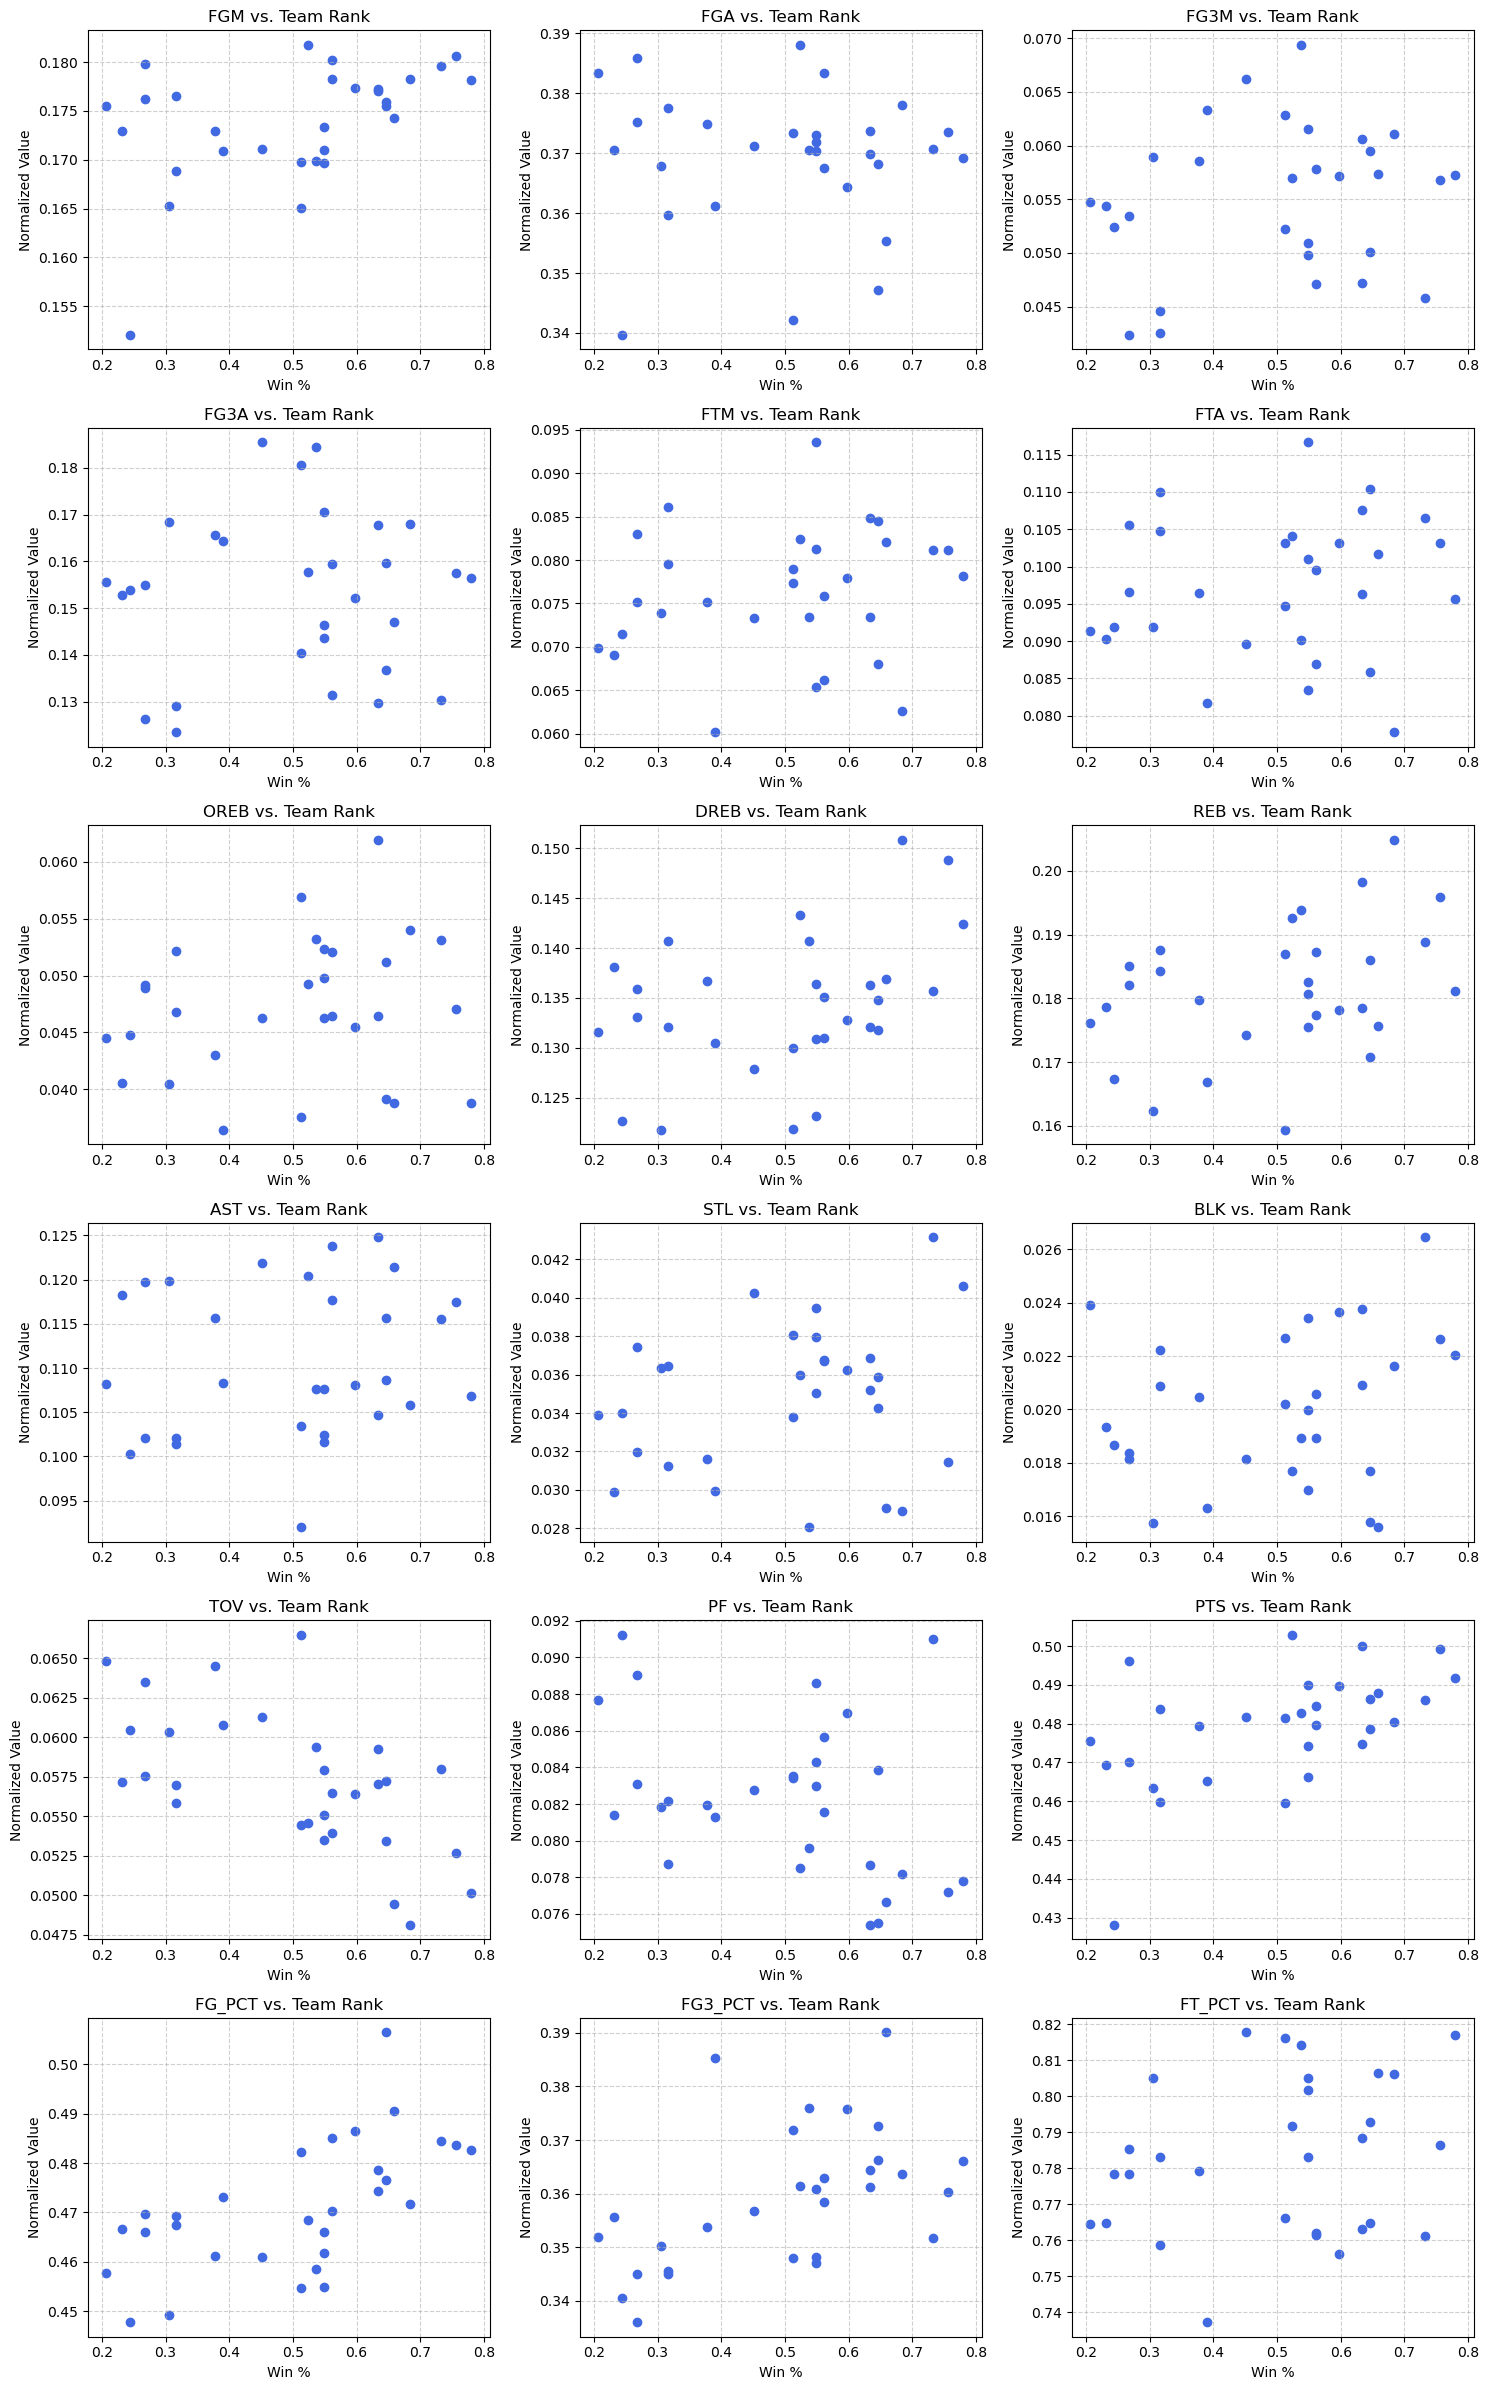

In [13]:
# Define grid dimensions: 3 columns and calculated rows
num_metrics = len(relevant_metrics)
cols = 3
rows = math.ceil(num_metrics / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
# Flatten axes array for easy iteration
axes = axes.flatten()

for i, metric in enumerate(relevant_metrics):
    # Plot metric on its own subplot
    axes[i].scatter(standings_stats['Win %'], standings_stats[metric], marker='o', color='royalblue', label=metric)
    
    # Customize the subplot
    axes[i].set_title(f"{metric} vs. Team Rank")
    axes[i].set_xlabel('Win %')
    axes[i].set_ylabel('Normalized Value')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove any unused subplot panels if the grid has leftover spaces
for j in range(len(relevant_metrics), len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and save
plt.tight_layout()

In [14]:
# Calculate the correlation matrix
correlation_matrix = standings_stats[['Rank'] + relevant_metrics].corr()

# Isolate the correlation with Rank and sort it
correlation_with_rank = correlation_matrix[['Rank']].sort_values(by='Rank')

# Display the correlation table
print("Correlation of Relevant Metrics with Team Rank:")
print(correlation_with_rank)

Correlation of Relevant Metrics with Team Rank:
             Rank
FG_PCT  -0.656505
FG3_PCT -0.514518
PTS     -0.512768
FGM     -0.483062
DREB    -0.417779
REB     -0.386048
BLK     -0.213618
STL     -0.191808
AST     -0.178938
FT_PCT  -0.172390
OREB    -0.168508
FTM     -0.130802
FG3M    -0.128361
FTA     -0.091255
FG3A     0.015740
FGA      0.043355
PF       0.378420
TOV      0.650039
Rank     1.000000


In [15]:
# Calculate the correlation matrix
correlation_matrix = standings_stats[['Win %'] + relevant_metrics].corr()

# Isolate the correlation with Rank and sort it
correlation_with_rank = correlation_matrix[['Win %']].sort_values(by='Win %', ascending=False)

# Display the correlation table
print("Correlation of Relevant Metrics with Win %:")
print(correlation_with_rank)

Correlation of Relevant Metrics with Win %:
            Win %
Win %    1.000000
FG_PCT   0.615177
PTS      0.525849
FG3_PCT  0.521434
FGM      0.445929
DREB     0.389864
REB      0.374370
BLK      0.232982
STL      0.229307
FT_PCT   0.228835
FG3M     0.184696
OREB     0.181094
FTM      0.165319
AST      0.137128
FTA      0.110124
FG3A     0.046184
FGA     -0.047059
PF      -0.372162
TOV     -0.599742


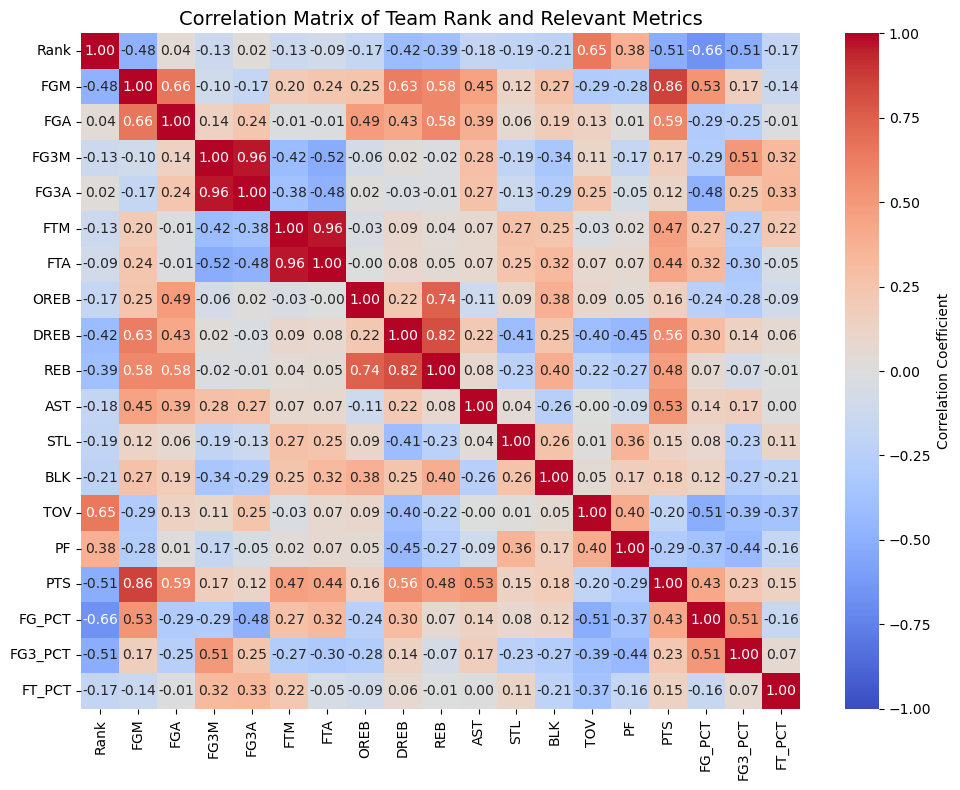

In [16]:
# Calculate the correlation matrix for Rank and relevant metrics
corr_matrix = standings_stats[['Rank'] + relevant_metrics].corr()

# Create the heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    ax=ax,
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Customize the plot
plt.title('Correlation Matrix of Team Rank and Relevant Metrics', fontsize=14)
plt.tight_layout()

### From Correlation table above, it is clear that Field Goals Made and Points scored is important for a high rank. This is to be expected because the winners natuarally score more points than their opponents. 

### It is interesting to look at what has negative correlation however. More Turnovers and Personal Fouls are correlated with a lower ranking. 

### Answer to #1: Top teams score points with increased efficiency as seen by Field Goal Percentage and 3-Point Percentage. They also turn the ball over less and commit less fouls.

# 2. Do teams need many good players or is one superstar enough?
### I belive the NBA is a star's league where the best players can have outsized returns on a team's success. I want to see what the distribution of the top/bottom team's points looks like.

Processing Top 5 Teams...


C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


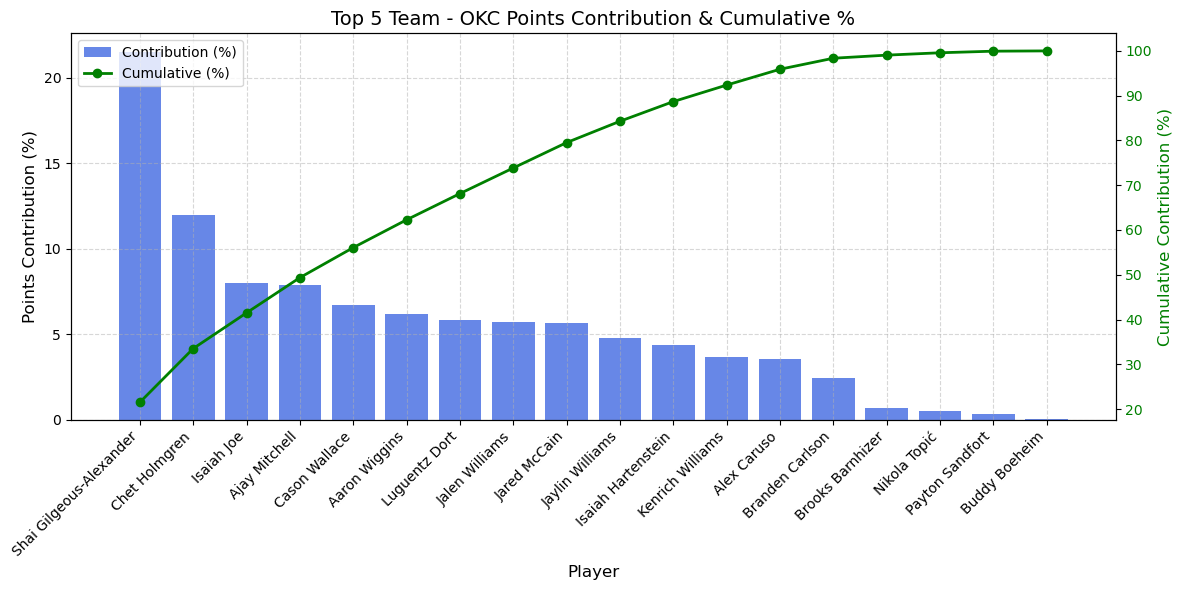

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


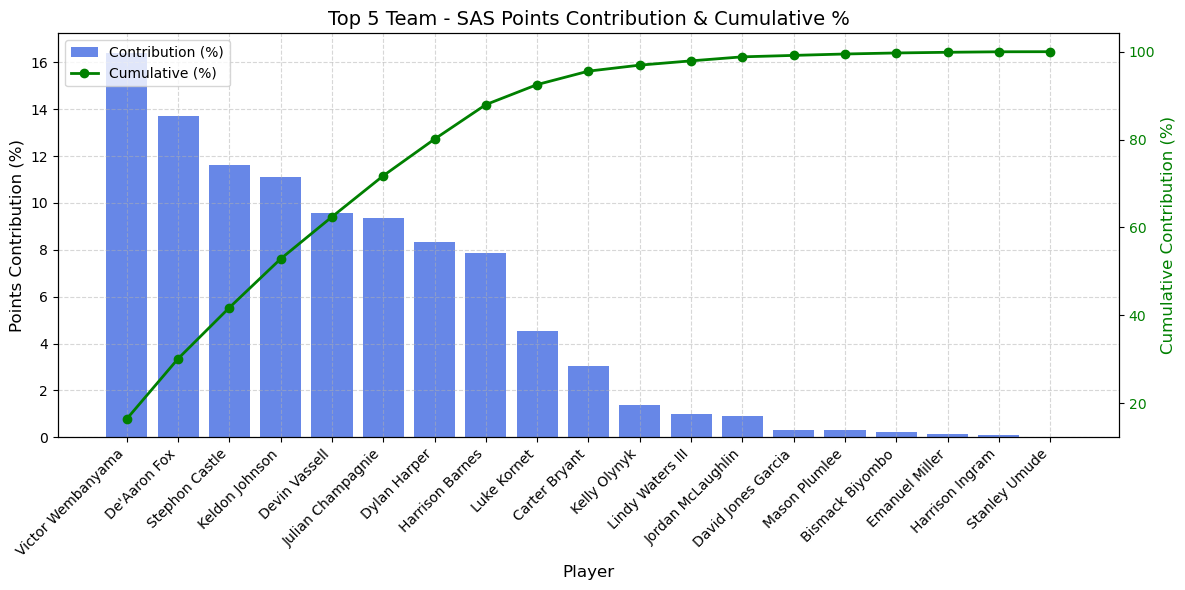

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


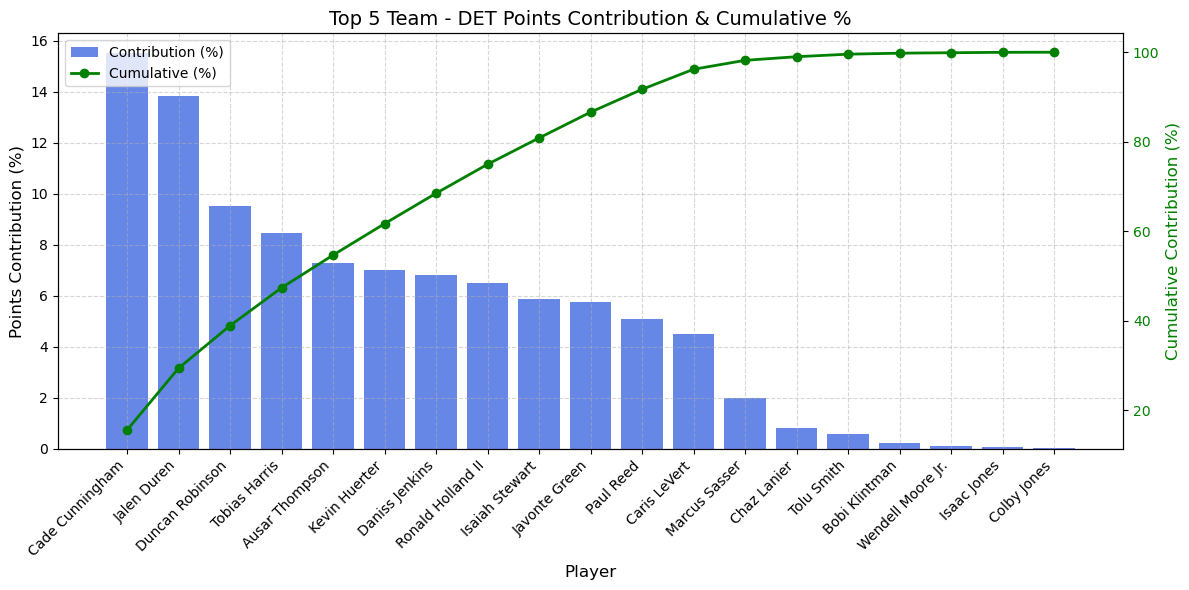

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


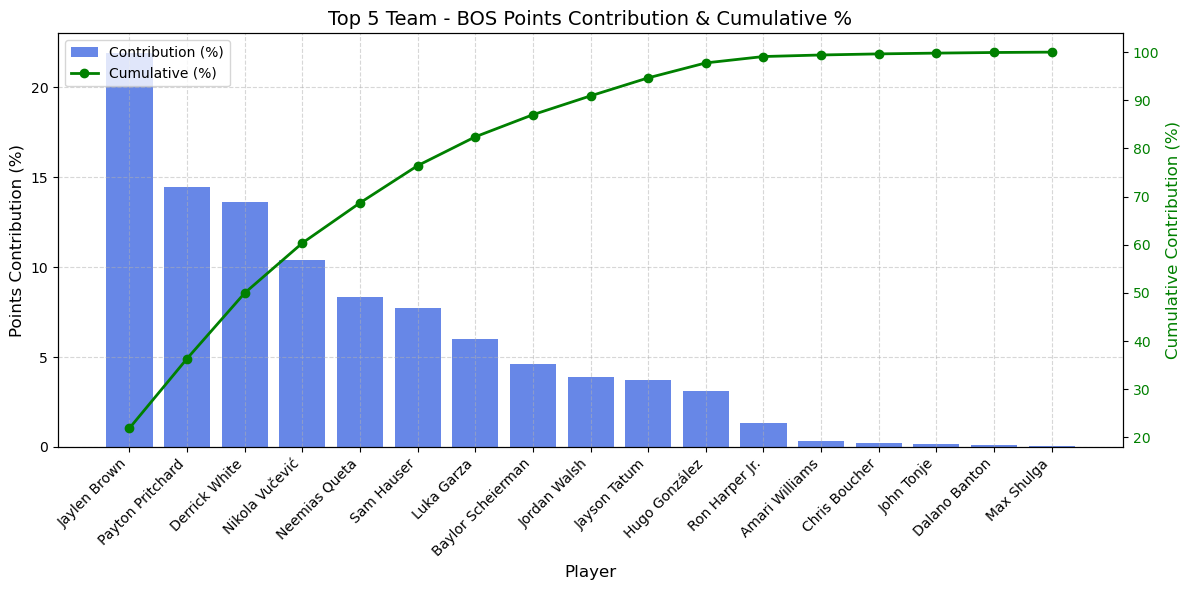

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


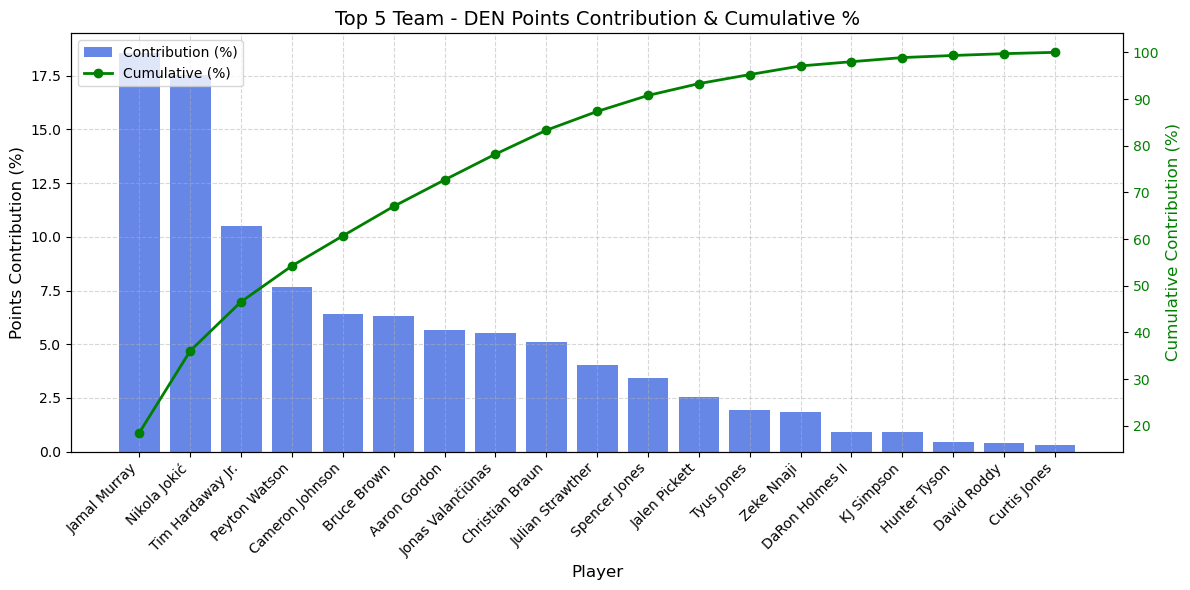


Processing Bottom 5 Teams...


C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


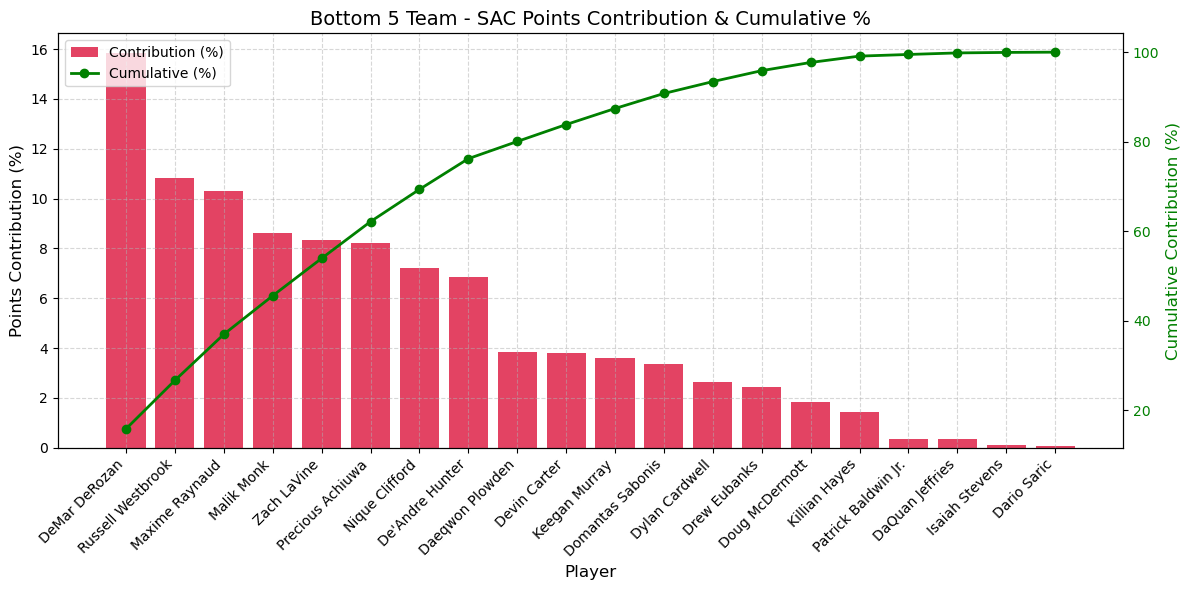

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


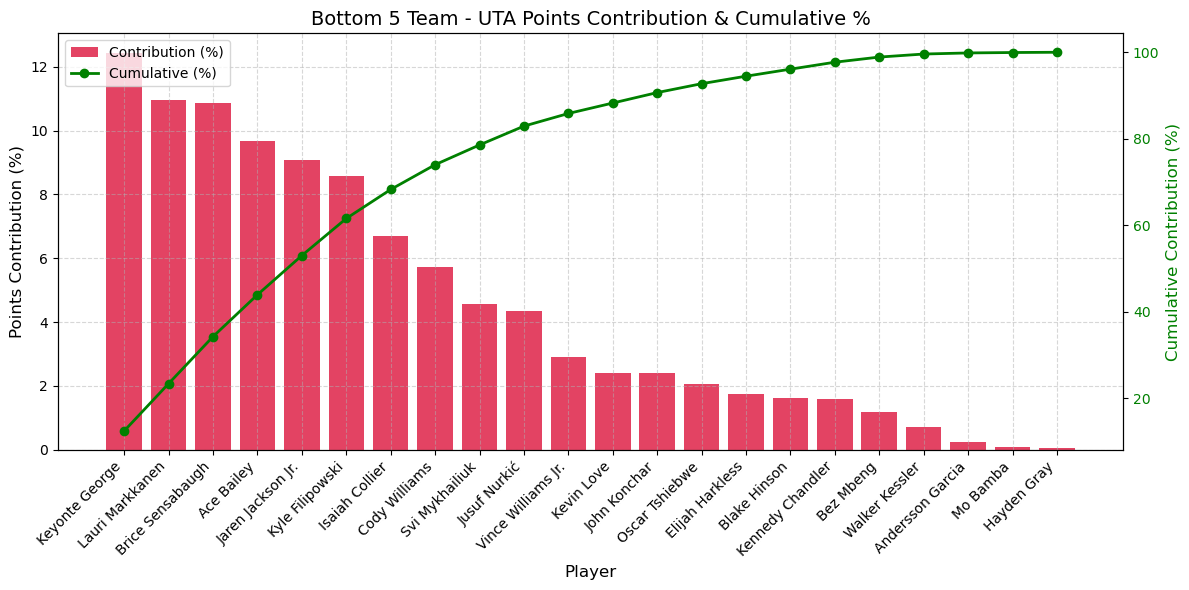

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


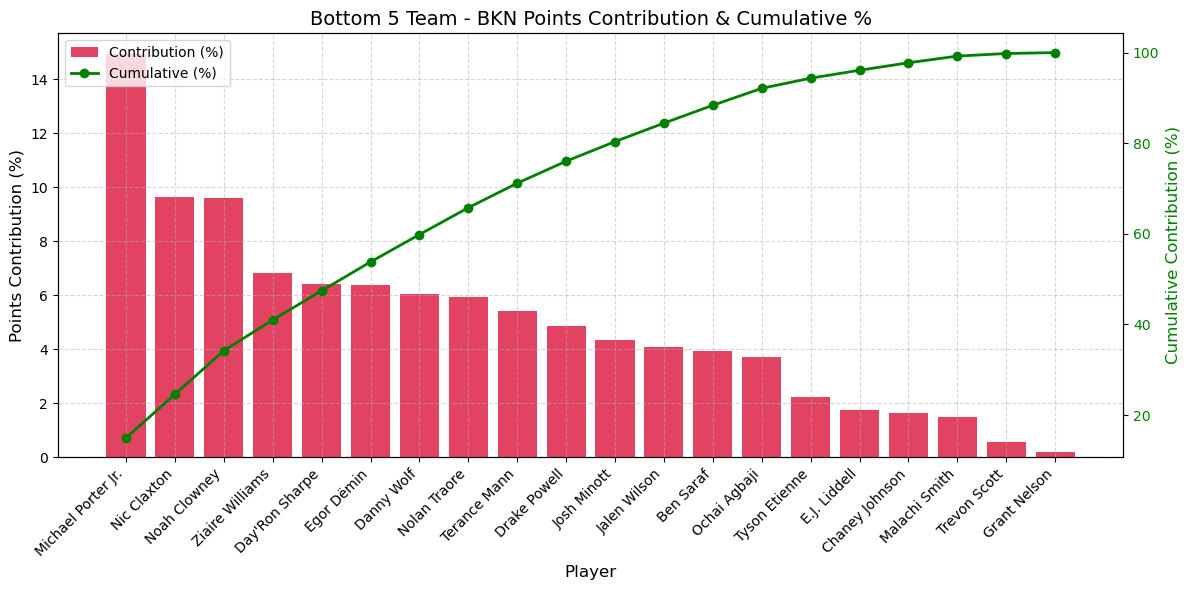

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


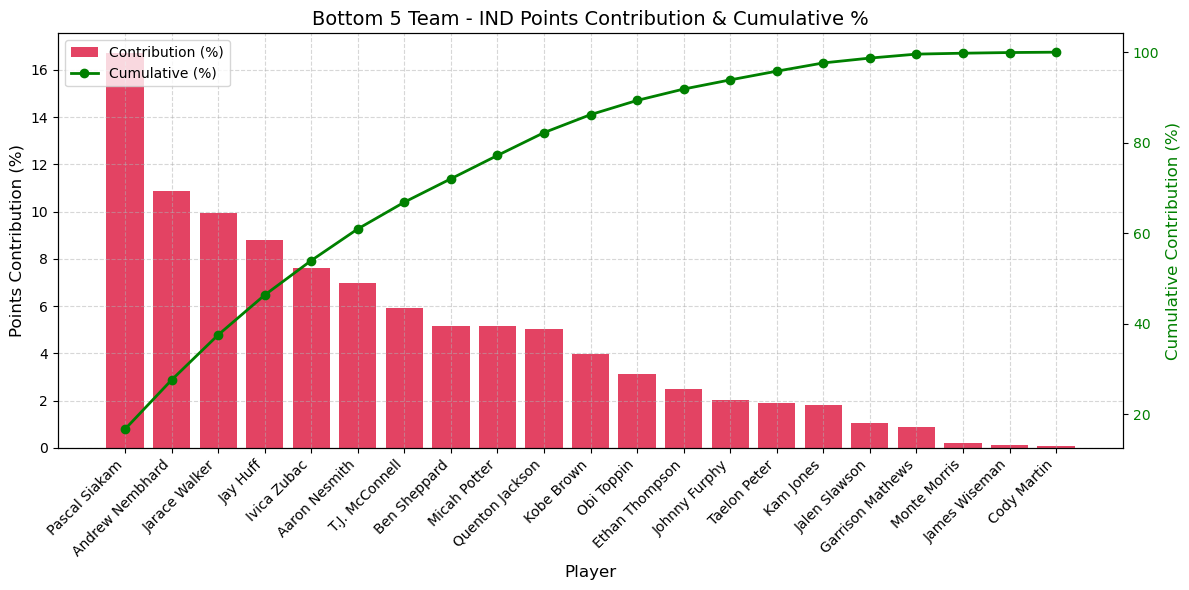

C:\Users\omega\AppData\Local\Temp\ipykernel_26184\2761761281.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')


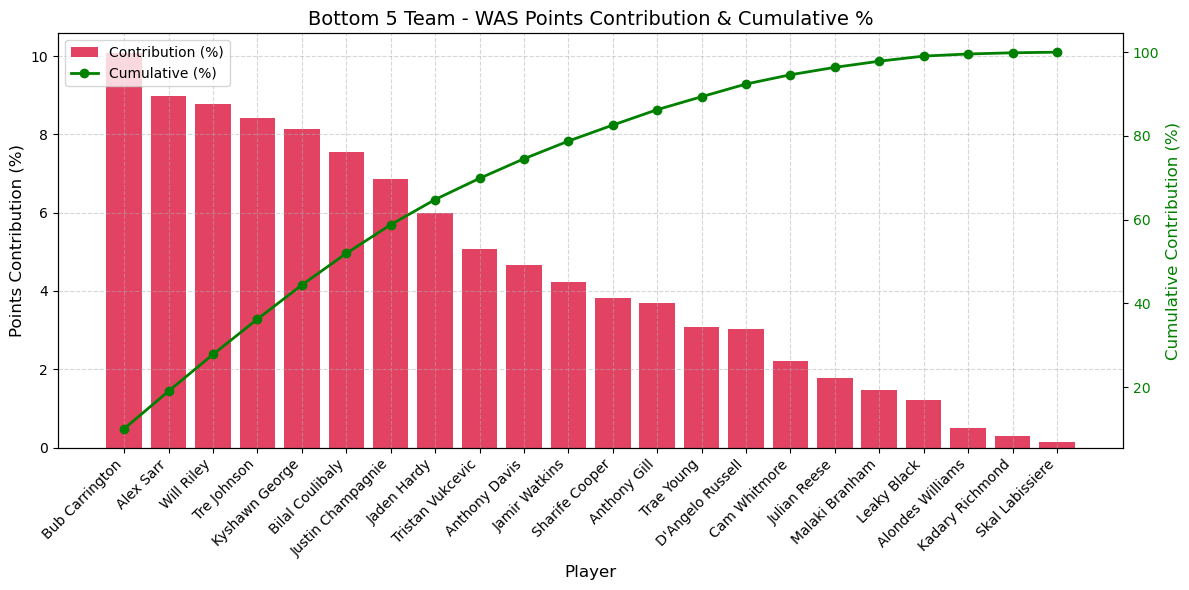

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Determine top and bottom 5 teams based on standings rank
top_5_teams = standings.sort_values(by='Rank', ascending=True).head(5)['Team'].tolist()
bottom_5_teams = standings.sort_values(by='Rank', ascending=True).tail(5)['Team'].tolist()

# Function to generate and display the Pareto contribution charts
def plot_pareto_charts(teams_list, category_name):
    for team in teams_list:
        # Filter for the specific team
        team_df = df[df['TEAM'] == team].copy()
        
        # Calculate percentage contribution
        team_df['PTS_Contribution'] = (team_df['PTS'] / team_df['PTS'].sum()) * 100
        team_df = team_df.sort_values(by='PTS_Contribution', ascending=False)
        team_df = team_df.reset_index(drop=True)
        
        # Calculate cumulative percentage
        team_df['Cumulative_Contribution'] = team_df['PTS_Contribution'].cumsum()
        
        # Create the figure
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Bar Chart: Contribution
        ax1.bar(
            team_df['PLAYER'], 
            team_df['PTS_Contribution'], 
            color='royalblue' if 'Top' in category_name else 'crimson', 
            alpha=0.8, 
            label='Contribution (%)'
        )
        
        ax1.set_xlabel('Player', fontsize=12)
        ax1.set_ylabel('Points Contribution (%)', color='black', fontsize=12)
        ax1.set_title(f"{category_name} - {team} Points Contribution & Cumulative %", fontsize=14)
        
        # Formatting x-ticks
        ax1.set_xticklabels(team_df['PLAYER'], rotation=45, ha='right')
        
        # Secondary y-axis for the cumulative line
        ax2 = ax1.twinx()
        ax2.plot(
            team_df['PLAYER'], 
            team_df['Cumulative_Contribution'], 
            color='green', 
            marker='o', 
            linewidth=2, 
            label='Cumulative (%)'
        )
        ax2.set_ylabel('Cumulative Contribution (%)', color='green', fontsize=12)
        ax2.tick_params(axis='y', labelcolor='green')
        
        # Grid and layout
        ax1.grid(True, linestyle='--', alpha=0.5)
        
        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        plt.tight_layout()
        plt.show()
        
        # Save to file
        plt.close(fig)

# 2. Generate charts
print("Processing Top 5 Teams...")
plot_pareto_charts(top_5_teams, "Top 5 Team")

print("\nProcessing Bottom 5 Teams...")
plot_pareto_charts(bottom_5_teams, "Bottom 5 Team")

### Answer to #2: It's difficult to draw any conclusions from the above chart and more rigorous analysis is needed. However, regardless of ranking, the top players are contributing a large percentage of points to their team. It is interesting to see that an MVP candidate like Shai Gilgeous-Alexander is contributing over 20% of his team's points. This leads me to my next question...

# 3. Are the players with a large point share, efficient or are they just shooting a lot of shots?

In [18]:
# 1. Calculate total points for each team
team_totals = df.groupby('TEAM')['PTS'].sum().reset_index()
team_totals.rename(columns={'PTS': 'TEAM_PTS'}, inplace=True)

# 2. Calculate totals per player
# (Assuming your dataframe has FGM, FGA, FG3M, FG3A, FTM, FTA, MIN, GP columns)
player_totals = df.groupby(['TEAM', 'PLAYER']).agg({
    'PTS': 'sum',
    'MIN': 'sum',
    'GP': 'sum',
    'FGM': 'sum',
    'FGA': 'sum',
    'FG3M': 'sum',
    'FG3A': 'sum',
    'FTM': 'sum',
    'FTA': 'sum'
}).reset_index()

# 3. Find the highest-scoring player for each team
top_players = player_totals.sort_values('PTS', ascending=False).drop_duplicates('TEAM').copy()

# 4. Merge with team totals and calculate the percentage contribution
top_players = top_players.merge(team_totals, on='TEAM')
top_players['Top_Player_Pct'] = (top_players['PTS'] / top_players['TEAM_PTS']) * 100

# 5. Calculate new requested metrics
top_players['FG_PCT'] = top_players['FGM'] / top_players['FGA']
top_players['FG3_PCT'] = top_players['FG3M'] / top_players['FG3A']
top_players['FT_PCT'] = top_players['FTM'] / top_players['FTA']
top_players['PTS_per_MIN'] = top_players['PTS'] / top_players['MIN']
top_players['PTS_per_G'] = top_players['PTS'] / top_players['GP']

# 6. Merge with the standings dataframe to get the rank (assuming the standings df has 'Team' and 'Rank' columns)
top_players = top_players.merge(standings[['Team', 'Rank']], left_on='TEAM', right_on='Team')

# 7. Sort by percentage in descending order
top_players = top_players.sort_values('Top_Player_Pct', ascending=False).reset_index(drop=True)

# 8. Select and rename columns for a clean DataFrame
top_players_df = top_players[['TEAM', 'Rank', 'PLAYER', 'PTS', 'TEAM_PTS', 'Top_Player_Pct', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'PTS_per_MIN', 'PTS_per_G','FTM']].copy()
top_players_df.columns = ['Team', 'Rank', 'Player', 'Player_PTS', 'Team_PTS', 'Contribution_Pct', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'PTS_per_MIN', 'PTS_per_G','FTM']

# 9. Write the DataFrame to CSV and display
top_players_df.to_csv('top_player_contributions.csv', index=False)
top_players_df.head()

,Team,Rank,Player,Player_PTS,Team_PTS,Contribution_Pct,FG_PCT,FG3_PCT,FT_PCT,PTS_per_MIN,PTS_per_G,FTM
0,LAL,7,Luka Dončić,2143,9766,21.943477,0.475635,0.365994,0.779845,0.936217,33.484375,503
1,BOS,4,Jaylen Brown,2038,9303,21.906912,0.476993,0.346535,0.794776,0.834220,28.704225,426
2,OKC,1,Shai Gilgeous-Alexander,2117,9840,21.514228,0.553369,0.385906,0.879479,0.937140,31.132353,540
3,HOU,9,Kevin Durant,2026,9449,21.441422,0.520349,0.413333,0.873662,0.713380,25.974359,408
4,LAC,19,Kawhi Leonard,1813,8683,20.879880,0.504769,0.386517,0.891827,0.869544,27.892308,371


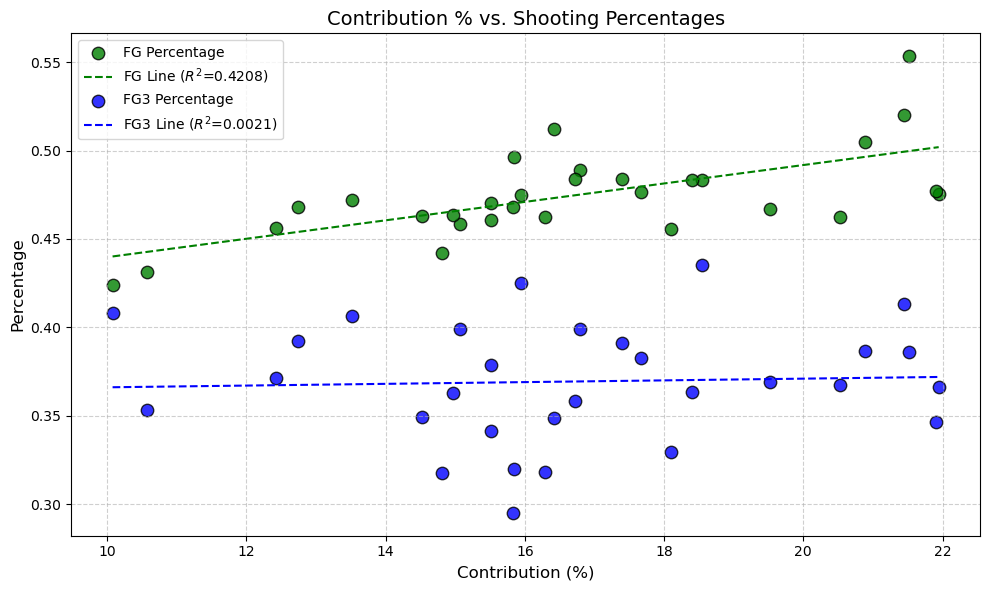

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# Drop NaN values for linear regression for each metric
valid_fg = top_players_df[['Contribution_Pct', 'FG_PCT']].dropna()
valid_fg3 = top_players_df[['Contribution_Pct', 'FG3_PCT']].dropna()

x_fg = valid_fg['Contribution_Pct']
y_fg = valid_fg['FG_PCT']
x_fg3 = valid_fg3['Contribution_Pct']
y_fg3 = valid_fg3['FG3_PCT']

# Calculate linear regression for FG Percentage
slope_fg, intercept_fg, r_value_fg, p_value_fg, std_err_fg = linregress(x_fg, y_fg)
r_squared_fg = r_value_fg ** 2

# Calculate linear regression for FG3 Percentage
slope_fg3, intercept_fg3, r_value_fg3, p_value_fg3, std_err_fg3 = linregress(x_fg3, y_fg3)
r_squared_fg3 = r_value_fg3 ** 2

# FG Percentage in green
ax.scatter(
    x_fg, 
    y_fg, 
    color='green', 
    s=80, 
    edgecolors='black',
    alpha=0.8,
    label='FG Percentage'
)

# Plot FG Regression line
x_sort_fg = np.sort(x_fg)
ax.plot(
    x_sort_fg, 
    slope_fg * x_sort_fg + intercept_fg, 
    color='green', 
    linestyle='--', 
    label=f'FG Line ($R^2$={r_squared_fg:.4f})'
)

# FG3 Percentage in blue
ax.scatter(
    x_fg3, 
    y_fg3, 
    color='blue', 
    s=80, 
    edgecolors='black',
    alpha=0.8,
    label='FG3 Percentage'
)

# Plot FG3 Regression line
x_sort_fg3 = np.sort(x_fg3)
ax.plot(
    x_sort_fg3, 
    slope_fg3 * x_sort_fg3 + intercept_fg3, 
    color='blue', 
    linestyle='--', 
    label=f'FG3 Line ($R^2$={r_squared_fg3:.4f})'
)

# Titles and labels
ax.set_title('Contribution % vs. Shooting Percentages', fontsize=14)
ax.set_xlabel('Contribution (%)', fontsize=12)
ax.set_ylabel('Percentage', fontsize=12)

# Formatting
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Answer to #3: It appears that the top scorers on each team are more efficient on regular field goals, but not 3-pointers. 

### Another factor is fouls though. If a player is fouled on a shot, it is not counted as a miss so these percentages don't tell the whole story.

### I will look at free throw attempts as well since these are likely high also. A top player knows how to get to the free throw line for easy points.

# 4. What percentage of top players' points come from free throws?
### For this question, I will define top player as any player with over 15% of their team's total points scored. These are the stars on their respective teams. 

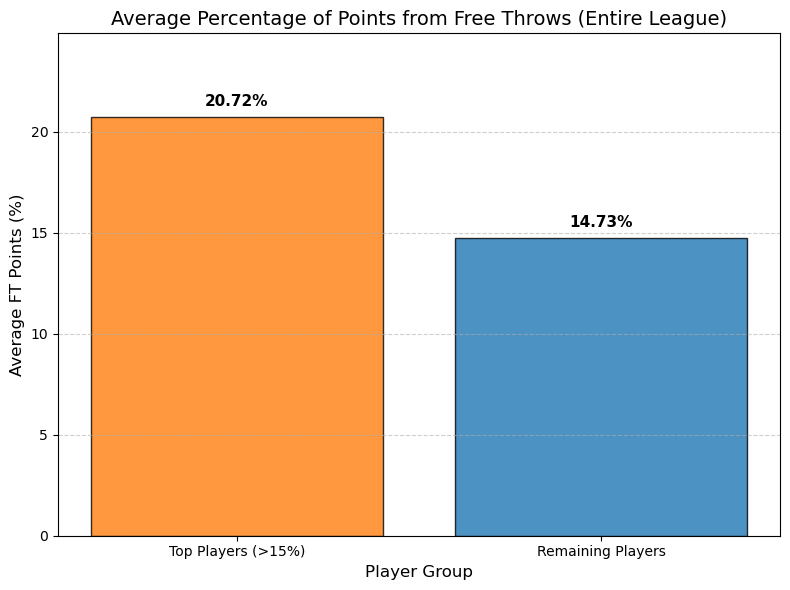

In [20]:
# 2. Calculate Contribution_Pct if it doesn't exist in the whole league dataframe
if 'Contribution_Pct' not in df.columns:
    df['Team_PTS'] = df.groupby('TEAM')['PTS'].transform('sum')
    df['Contribution_Pct'] = (df['PTS'] / df['Team_PTS']) * 100

# 3. Calculate FT_Points_Pct using FTM (assuming each free throw is 1 point)
# Points from Free Throws = FTM * 1
if 'FT_Points_Pct' not in df.columns:
    # Use FTM and PTS to get the free throw points percentage
    df['FT_Points_Pct'] = (df['FTM'] / df['PTS']) * 100
    
    # Handle any potential division by zero or NaN values
    df['FT_Points_Pct'] = df['FT_Points_Pct'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Group the entire league's players by Contribution Percentage
top_players_group = df[df['Contribution_Pct'] > 15]
remaining_players_group = df[df['Contribution_Pct'] <= 15]

# Calculate the average percentage of points from free throws for each group
avg_ft_top = top_players_group['FT_Points_Pct'].mean()
avg_ft_remaining = remaining_players_group['FT_Points_Pct'].mean()

# 5. Prepare data for the bar chart
categories = ['Top Players (>15%)', 'Remaining Players']
means = [avg_ft_top, avg_ft_remaining]

# 6. Create the bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(categories, means, color=['#ff7f0e', '#1f77b4'], edgecolor='black', alpha=0.8)

# 7. Titles and labels
ax.set_title('Average Percentage of Points from Free Throws (Entire League)', fontsize=14)
ax.set_xlabel('Player Group', fontsize=12)
ax.set_ylabel('Average FT Points (%)', fontsize=12)

# 8. Formatting
ax.set_ylim(0, max(means) * 1.2) # Add some padding to the top of the chart
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 9. Add text annotations on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (max(means) * 0.02), f'{yval:.2f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Save and display
plt.tight_layout()
plt.show()

### Answer to #4: As show above, the top players are averaging 20.72% of their points from Free Throws. The rest of the league is 6% lower. 

### Top players are clearly utilizing Free Throws to get easy buckets.

# 5. Do top players favor 3-pointers?
### Again, top players are defined as any player with over 15% of their team's total points score

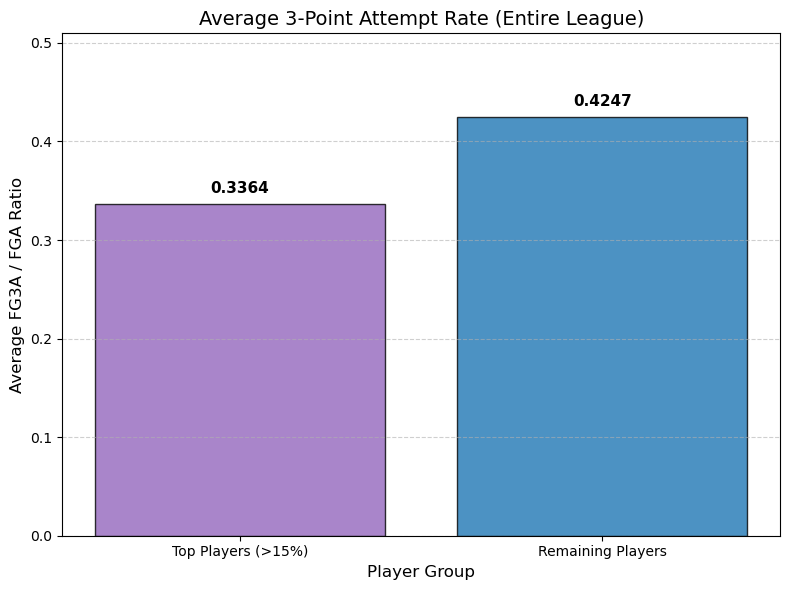

In [21]:
# 2. Calculate Contribution_Pct if it doesn't exist in the whole league dataframe
if 'Contribution_Pct' not in df.columns:
    df['Team_PTS'] = df.groupby(team_col)['PTS'].transform('sum')
    df['Contribution_Pct'] = (df['PTS'] / df['Team_PTS']) * 100

# 3. Calculate FG3A_Rate if it doesn't exist in the whole league dataframe
if 'FG3A_Rate' not in df.columns:
    # Use FG3A and FGA to get the 3-point attempt rate, avoiding division by zero
    df['FG3A_Rate'] = np.where(df['FGA'] > 0, df['FG3A'] / df['FGA'], 0)
    df['FG3A_Rate'] = df['FG3A_Rate'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Group the entire league's players by Contribution Percentage
top_players_group = df[df['Contribution_Pct'] > 15]
remaining_players_group = df[df['Contribution_Pct'] <= 15]

# Calculate the average 3-Point Attempt Rate for each group
avg_fg3a_top = top_players_group['FG3A_Rate'].mean()
avg_fg3a_remaining = remaining_players_group['FG3A_Rate'].mean()

# 5. Prepare data for the bar chart
categories = ['Top Players (>15%)', 'Remaining Players']
means = [avg_fg3a_top, avg_fg3a_remaining]

# 6. Create the bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(categories, means, color=['#9467bd', '#1f77b4'], edgecolor='black', alpha=0.8)

# 7. Titles and labels
ax.set_title('Average 3-Point Attempt Rate (Entire League)', fontsize=14)
ax.set_xlabel('Player Group', fontsize=12)
ax.set_ylabel('Average FG3A / FGA Ratio', fontsize=12)

# 8. Formatting
ax.set_ylim(0, max(means) * 1.2) # Add some padding to the top of the chart
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 9. Add text annotations on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (max(means) * 0.02), f'{yval:.4f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Save and display
plt.tight_layout()
plt.show()

### Answer to #5: To my surprise, the top players do not favor 3 point shots. They are averaging 0.3364 3-point attempts per overall field goal attempts. This is 0.0883 attempts (8.83%) lower than the rest of the league. 

### Combining this with the knowledge about free throw attempts, leads me to believe that top players are not settling for 3-pointers and they are often attacking the basket (where they are subsequently fouled).

# Summary
### The top teams are scoring more due to increased efficiency (field goal % and 3-point percentage). They are also committing fewer turnovers and personal fouls. 
### There are stars on each team which score an outsized portion of the overal team's points. They are efficient with overall field goals, but not necessarily 3-pointers. In fact, they shoot 8.83% fewer 3-pointers on average than the rest of the league. They also prioritize getting to the free throw line and get 20.72% of their overall points from free throws versus the rest of the league at 14.73%